In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [3]:
from pathlib import Path
data_path = Path("data-change-detection/")

In [4]:
check_data(data_path)

# of directories: 3 and 0 images in 'data-change-detection'.
# of directories: 3 and 0 images in 'data-change-detection\test'.
# of directories: 0 and 128 images in 'data-change-detection\test\A'.
# of directories: 0 and 128 images in 'data-change-detection\test\B'.
# of directories: 0 and 128 images in 'data-change-detection\test\label'.
# of directories: 3 and 0 images in 'data-change-detection\train'.
# of directories: 0 and 445 images in 'data-change-detection\train\A'.
# of directories: 0 and 445 images in 'data-change-detection\train\B'.
# of directories: 0 and 445 images in 'data-change-detection\train\label'.
# of directories: 3 and 0 images in 'data-change-detection\val'.
# of directories: 0 and 64 images in 'data-change-detection\val\A'.
# of directories: 0 and 64 images in 'data-change-detection\val\B'.
# of directories: 0 and 64 images in 'data-change-detection\val\label'.


In [5]:
train_dir = data_path / "train"
test_dir = data_path / "test"
val_dir = data_path / "val"

In [6]:
# let's actually see some images
import random
from PIL import Image


# 1. Get all image paths 
image_path_list = list(train_dir.glob("*/*.png"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

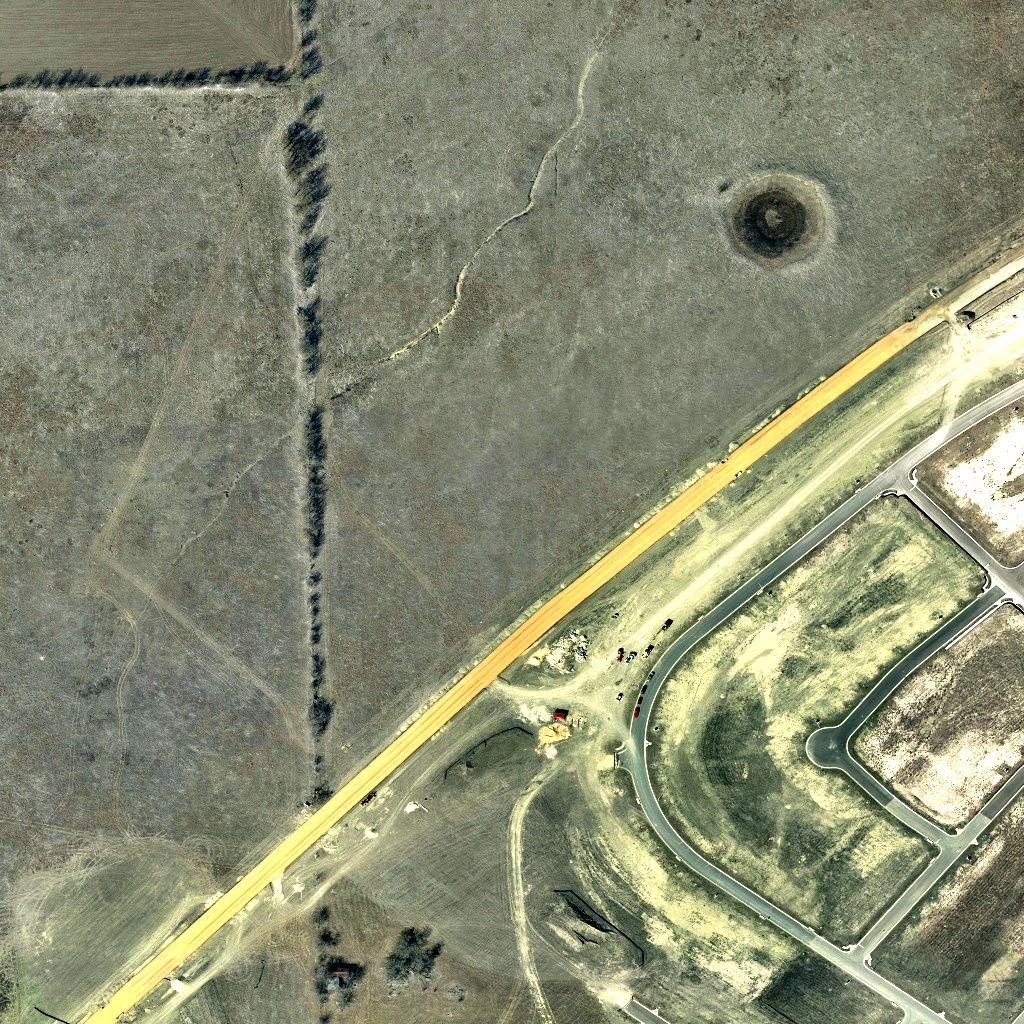

In [7]:
img

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
from torch.utils.data import Dataset
from torchvision.transforms import functional as TF

class ChangeDetectionDataset(Dataset):
    def __init__(self, root_dir, crop_size=None, augment=False):
        self.root_dir = Path(root_dir)
        self.crop_size = crop_size # None = keep the full 1024x1024 image
        self.augment = augment     # True = random flips (only for training)
        # The same file name exists in A, B and label, so one list of names is enough
        self.file_names = sorted(p.name for p in (self.root_dir / "A").glob("*.png"))
        print(self.file_names[0])

    def __len__(self):
        # Number of pairs (not number of image files)
        return len(self.file_names)

    def __getitem__(self, idx):
        file_name = self.file_names[idx]

        # 1. Open the three images that belong to the same pair
        img_a = Image.open(self.root_dir / "A" / file_name).convert("RGB")
        img_b = Image.open(self.root_dir / "B" / file_name).convert("RGB")
        mask = Image.open(self.root_dir / "label" / file_name).convert("L")

        # 2. Random crop: pick ONE random location and cut the same square from all three
        if self.crop_size is not None:
            top, left, height, width = transforms.RandomCrop.get_params(img_a, output_size=(self.crop_size, self.crop_size))
            img_a = TF.crop(img_a, top, left, height, width)
            img_b = TF.crop(img_b, top, left, height, width)
            mask = TF.crop(mask, top, left, height, width)

        # 3. Random flips: decide ONCE, then apply to all three
        if self.augment:
            if random.random() < 0.5:
                img_a, img_b, mask = TF.hflip(img_a), TF.hflip(img_b), TF.hflip(mask)
            if random.random() < 0.5:
                img_a, img_b, mask = TF.vflip(img_a), TF.vflip(img_b), TF.vflip(mask)

        # 4. Turn them into tensors (values between 0 and 1)
        img_a = TF.to_tensor(img_a) # [3, H, W]
        img_b = TF.to_tensor(img_b) # [3, H, W]
        mask = TF.to_tensor(mask)   # [1, H, W]

        # 5. Make the mask exactly 0 or 1 (0 = no change, 1 = change)
        mask = (mask > 0.5).float()

        return img_a, img_b, mask

In [10]:
CROP_SIZE = 256

# Training: random 256x256 crops + flips. Validation/test: full images, no randomness
train_data = ChangeDetectionDataset(train_dir, crop_size=CROP_SIZE, augment=True)
val_data = ChangeDetectionDataset(val_dir)
test_data = ChangeDetectionDataset(test_dir)

print(f"Number of pairs: {len(train_data)} train, {len(val_data)} val, {len(test_data)} test")

img_a, img_b, mask = train_data[0]
print(img_a.shape, img_b.shape, mask.shape)
print(f"Mask values: {mask.unique()}")

train_1.png
val_1.png
test_1.png
Number of pairs: 445 train, 64 val, 128 test
torch.Size([3, 256, 256]) torch.Size([3, 256, 256]) torch.Size([1, 256, 256])
Mask values: tensor([0., 1.])


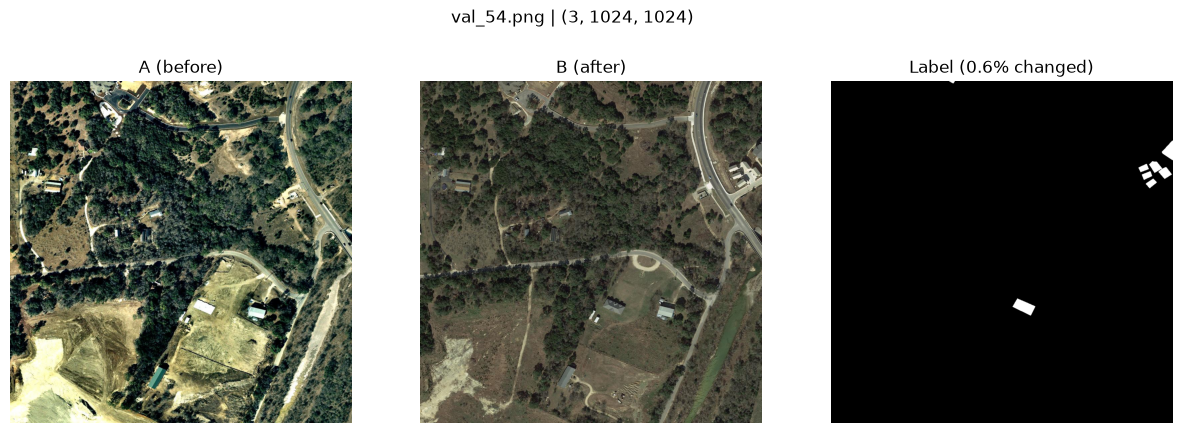

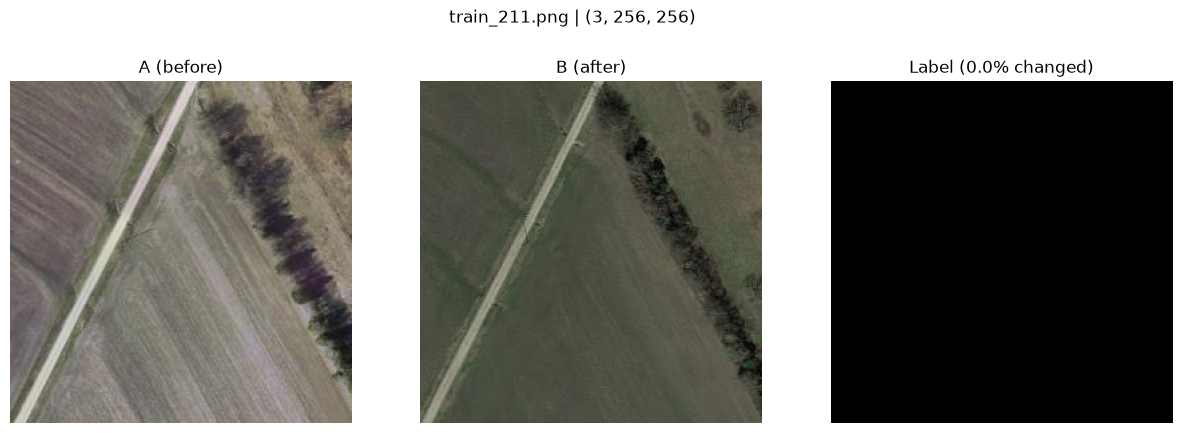

In [20]:
import matplotlib.pyplot as plt

def show_pair(dataset, idx=None):
    # Shows image A, image B and the label of the same pair side by side
    if idx is None:
        idx = random.randint(0, len(dataset) - 1) # random pair if no index is given
    img_a, img_b, mask = dataset[idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_a.permute(1, 2, 0)) # [3, H, W] -> [H, W, 3] for matplotlib
    axes[0].set_title("A (before)")
    axes[1].imshow(img_b.permute(1, 2, 0))
    axes[1].set_title("B (after)")
    axes[2].imshow(mask.squeeze(), cmap="gray", vmin=0, vmax=1) # [1, H, W] -> [H, W], white = change
    axes[2].set_title(f"Label ({mask.mean() * 100:.1f}% changed)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{dataset.file_names[idx]} | {tuple(img_a.shape)}")
    plt.show()

show_pair(val_data)   # full 1024x1024 image
show_pair(train_data) # random 256x256 crop with flips

In [12]:
mask

tensor([[[0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [13]:
BATCH_SIZE = 16 # 32 needs ~10 GB of GPU memory with this model, 16 needs ~5 GB
NUM_WORKERS = 0 

train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) 

# val and test images are full size (1024x1024), so the batch has to be small
val_dataloader = DataLoader(dataset=val_data,
                            batch_size=2, 
                            num_workers=NUM_WORKERS, 
                            shuffle=False)
test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=2, 
                             num_workers=NUM_WORKERS, 
                             shuffle=False)

img_a, img_b, mask = next(iter(train_dataloader))
print(img_a.shape, img_b.shape, mask.shape)

torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256])


In [14]:
class ConvBlock(nn.Module):
    # Conv 3x3 -> BatchNorm -> ReLU, twice. 
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    # Shrinks the image step by step and returns the feature map of EVERY stage (the decoder needs all of them)
    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        self.stages = nn.ModuleList()
        in_channels = 3 # RGB
        for out_channels in channels:
            self.stages.append(ConvBlock(in_channels, out_channels))
            in_channels = out_channels
        self.pool = nn.MaxPool2d(kernel_size=2) # halves H and W

    def forward(self, x):
        features = []
        for i, stage in enumerate(self.stages):
            if i > 0:
                x = self.pool(x) # no pooling before the first stage, so it stays at full resolution
            x = stage(x)
            features.append(x)
        return features # [32ch 256x256, 64ch 128x128, 128ch 64x64, 256ch 32x32]


class Decoder(nn.Module):
    # Grows the smallest feature map back to full size, using the bigger ones on the way (skip connections)
    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False) # doubles H and W
        self.stages = nn.ModuleList()
        # From deepest to shallowest: (256 + 128) -> 128, (128 + 64) -> 64, (64 + 32) -> 32
        for i in range(len(channels) - 1, 0, -1):
            self.stages.append(ConvBlock(channels[i] + channels[i - 1], channels[i - 1]))

    def forward(self, features):
        x = features[-1] # start from the smallest map (32x32)
        for i, stage in enumerate(self.stages):
            skip = features[-(i + 2)]       # the map that is one size bigger
            x = self.upsample(x)            # make x the same size as skip
            x = torch.cat([x, skip], dim=1) # put them side by side on the channel dimension
            x = stage(x)
        return x # [32ch, 256x256]


class SiameseUNet(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        self.encoder = Encoder(channels) # ONE encoder, used for both images (shared weights)
        self.decoder = Decoder(channels)
        self.head = nn.Conv2d(channels[0], 1, kernel_size=1) # 32 channels -> 1 channel (change / no change)

    def forward(self, img_a, img_b):
        # 1. Same encoder for both images
        features_a = self.encoder(img_a)
        features_b = self.encoder(img_b)

        # 2. Fusion: absolute difference at every stage
        diffs = [torch.abs(fa - fb) for fa, fb in zip(features_a, features_b)]

        # 3. Decode the differences back to full resolution
        x = self.decoder(diffs)

        # 4. One raw score (logit) per pixel. No sigmoid here, the loss function applies it
        return self.head(x)

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SiameseUNet().to(device)

# Try the model with random tensors before any real training
dummy_a = torch.rand(2, 3, 256, 256).to(device)
dummy_b = torch.rand(2, 3, 256, 256).to(device)

print("Encoder outputs:")
for feature in model.encoder(dummy_a):
    print(f"  {feature.shape}")

output = model(dummy_a, dummy_b)
print(f"Model output: {output.shape}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Encoder outputs:
  torch.Size([2, 32, 256, 256])
  torch.Size([2, 64, 128, 128])
  torch.Size([2, 128, 64, 64])
  torch.Size([2, 256, 32, 32])
Model output: torch.Size([2, 1, 256, 256])
Number of parameters: 1,948,289


In [16]:
bce_loss_fn = nn.BCEWithLogitsLoss() # sigmoid + binary cross entropy, calculated for every pixel

def dice_loss(logits, mask):
    # Measures how much the predicted area overlaps the real area (0 = perfect overlap, 1 = no overlap)
    probs = torch.sigmoid(logits)
    intersection = (probs * mask).sum()
    return 1 - (2 * intersection + 1) / (probs.sum() + mask.sum() + 1) # +1 avoids dividing by zero on empty masks

def loss_fn(logits, mask):
    # BCE looks at every pixel on its own, Dice looks at the changed area as a whole
    return bce_loss_fn(logits, mask) + dice_loss(logits, mask)

def count_pixels(logits, mask):
    pred = (logits > 0).float() # logit > 0 is the same as sigmoid > 0.5
    tp = (pred * mask).sum().item()       # predicted change, really changed
    fp = (pred * (1 - mask)).sum().item() # predicted change, but no change
    fn = ((1 - pred) * mask).sum().item() # missed change
    return tp, fp, fn

def compute_metrics(tp, fp, fn):
    precision = tp / (tp + fp + 1e-8) # of the pixels we called "change", how many are right?
    recall = tp / (tp + fn + 1e-8)    # of the really changed pixels, how many did we find?
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)  # overlap / union of prediction and real mask
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

In [17]:
def train_step(model, dataloader, optimizer):
    model.train() # BatchNorm uses batch statistics
    total_loss, tp, fp, fn = 0, 0, 0, 0

    for img_a, img_b, mask in dataloader:
        img_a, img_b, mask = img_a.to(device), img_b.to(device), mask.to(device)

        # 1. Forward pass
        logits = model(img_a, img_b)

        # 2. Calculate the loss
        loss = loss_fn(logits, mask)

        # 3. Backward pass and weight update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 4. Keep the numbers for the epoch summary
        total_loss += loss.item()
        batch_tp, batch_fp, batch_fn = count_pixels(logits, mask)
        tp, fp, fn = tp + batch_tp, fp + batch_fp, fn + batch_fn

    return total_loss / len(dataloader), compute_metrics(tp, fp, fn)


def eval_step(model, dataloader):
    model.eval() # BatchNorm uses the statistics it learned during training
    total_loss, tp, fp, fn = 0, 0, 0, 0

    with torch.inference_mode(): # no gradients, less memory
        for img_a, img_b, mask in dataloader:
            img_a, img_b, mask = img_a.to(device), img_b.to(device), mask.to(device)

            logits = model(img_a, img_b)
            total_loss += loss_fn(logits, mask).item()
            batch_tp, batch_fp, batch_fn = count_pixels(logits, mask)
            tp, fp, fn = tp + batch_tp, fp + batch_fp, fn + batch_fn

    return total_loss / len(dataloader), compute_metrics(tp, fp, fn)

In [18]:
EPOCHS = 50
MODEL_PATH = "best_model.pth"

model = SiameseUNet().to(device) # fresh weights every time this cell runs
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": [], "val_iou": []}
best_val_f1 = 0

for epoch in range(EPOCHS):
    train_loss, train_metrics = train_step(model, train_dataloader, optimizer)
    val_loss, val_metrics = eval_step(model, val_dataloader)

    # Save the loss values and metrics of this epoch
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_iou"].append(val_metrics["iou"])

    # Keep the weights of the best epoch on disk
    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"Epoch {epoch + 1}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | "
          f"train_f1: {train_metrics['f1']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_iou: {val_metrics['iou']:.4f}")

Epoch 1/50 | train_loss: 1.4078 | val_loss: 2.3302 | train_f1: 0.2326 | val_f1: 0.1570 | val_iou: 0.0852
Epoch 2/50 | train_loss: 1.1888 | val_loss: 1.2762 | train_f1: 0.4800 | val_f1: 0.3218 | val_iou: 0.1917
Epoch 3/50 | train_loss: 1.0790 | val_loss: 1.3903 | train_f1: 0.4819 | val_f1: 0.2228 | val_iou: 0.1254
Epoch 4/50 | train_loss: 0.9783 | val_loss: 1.0424 | train_f1: 0.5215 | val_f1: 0.4366 | val_iou: 0.2792
Epoch 5/50 | train_loss: 0.8738 | val_loss: 1.2904 | train_f1: 0.5480 | val_f1: 0.2439 | val_iou: 0.1389
Epoch 6/50 | train_loss: 0.7618 | val_loss: 0.8055 | train_f1: 0.6192 | val_f1: 0.5916 | val_iou: 0.4201
Epoch 7/50 | train_loss: 0.7075 | val_loss: 0.9346 | train_f1: 0.6205 | val_f1: 0.3707 | val_iou: 0.2276
Epoch 8/50 | train_loss: 0.6111 | val_loss: 0.8021 | train_f1: 0.6640 | val_f1: 0.4947 | val_iou: 0.3286
Epoch 9/50 | train_loss: 0.6093 | val_loss: 1.0350 | train_f1: 0.6290 | val_f1: 0.1907 | val_iou: 0.1054
Epoch 10/50 | train_loss: 0.5717 | val_loss: 0.9009 | t

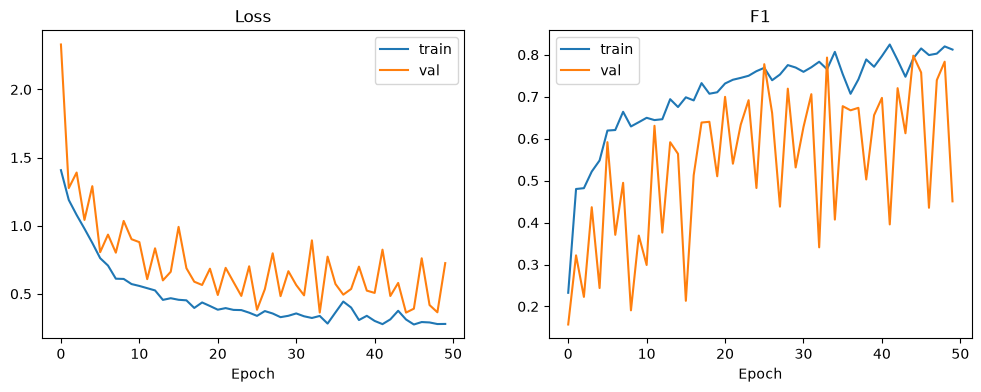

In [19]:
import matplotlib.pyplot as plt

fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(history["train_loss"], label="train")
ax_loss.plot(history["val_loss"], label="val")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.legend()

ax_f1.plot(history["train_f1"], label="train")
ax_f1.plot(history["val_f1"], label="val")
ax_f1.set_title("F1")
ax_f1.set_xlabel("Epoch")
ax_f1.legend()

In [21]:
# The model in memory has the weights of the LAST epoch. Load the weights of the BEST epoch instead
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

test_loss, test_metrics = eval_step(model, test_dataloader)

print(f"test_loss: {test_loss:.4f}")
for name, value in test_metrics.items():
    print(f"test_{name}: {value:.4f}")

test_loss: 0.4076
test_precision: 0.8347
test_recall: 0.7499
test_f1: 0.7900
test_iou: 0.6529


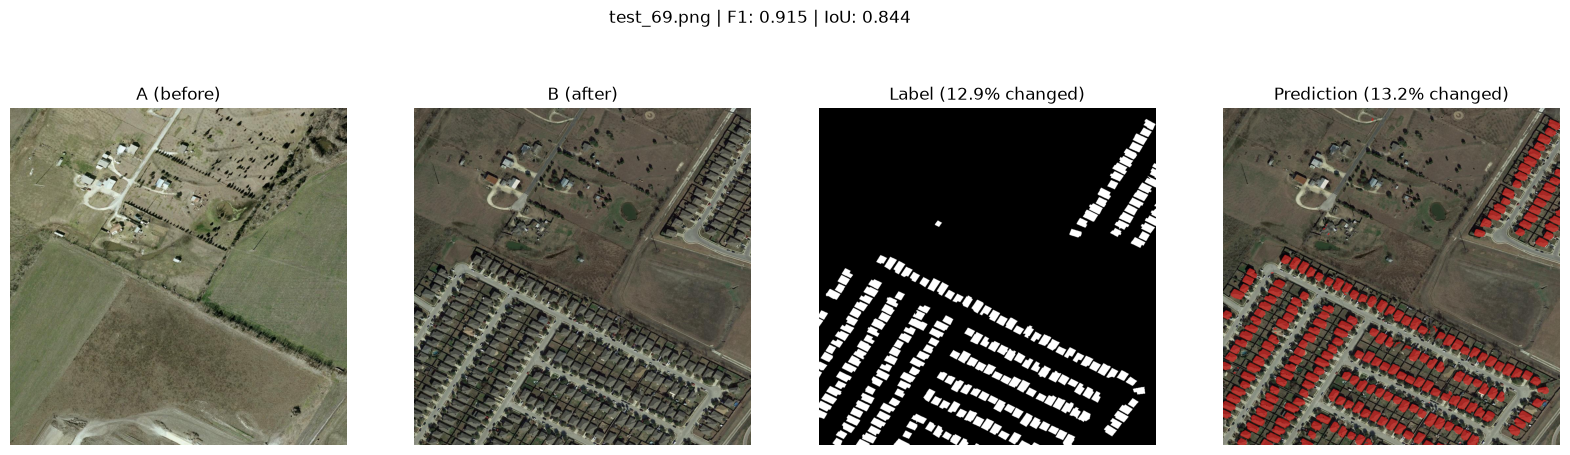

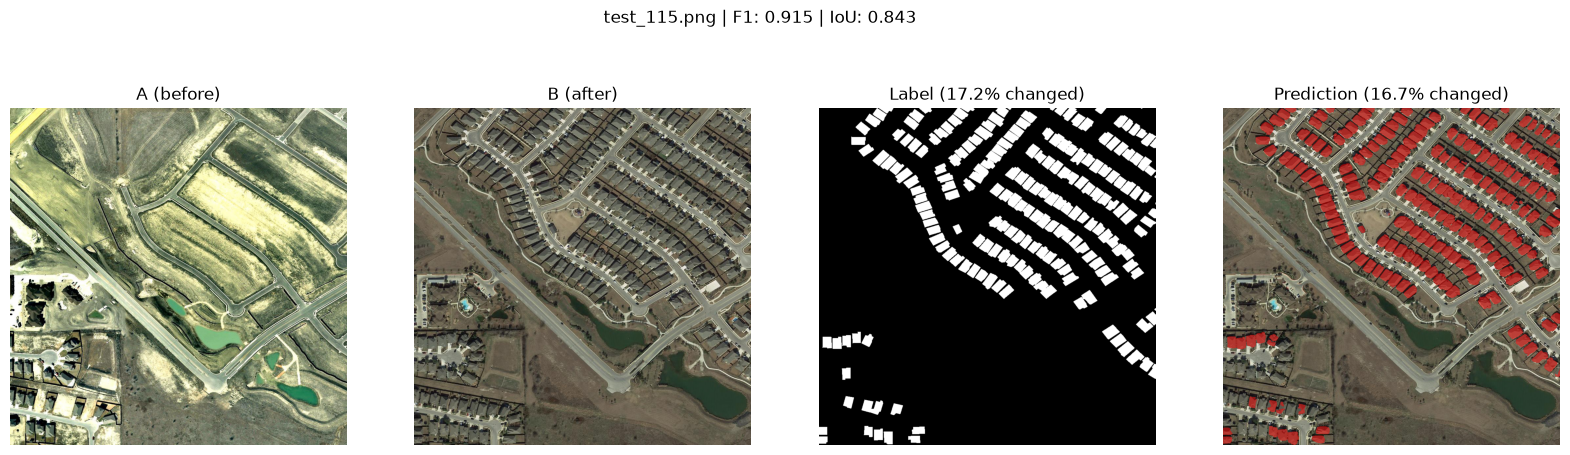

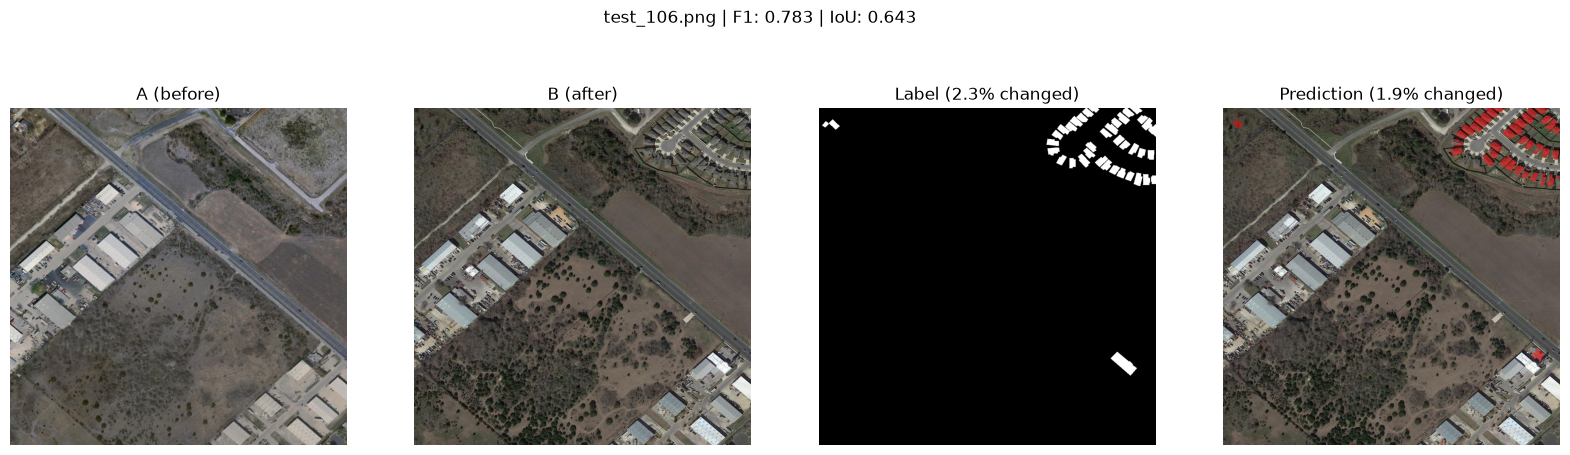

In [22]:
def show_prediction(dataset, idx=None):
    # Shows A, B, the real label and the model's prediction painted in red on top of image B
    if idx is None:
        idx = random.randint(0, len(dataset) - 1) # random pair if no index is given
    img_a, img_b, mask = dataset[idx]

    # 1. Run the model on this single pair (unsqueeze adds the batch dimension: [3, H, W] -> [1, 3, H, W])
    model.eval()
    with torch.inference_mode():
        logits = model(img_a.unsqueeze(0).to(device), img_b.unsqueeze(0).to(device))
    logits = logits.squeeze(0).cpu() # back to [1, H, W]
    pred = (logits > 0).squeeze()    # [H, W], True = the model says "changed"

    # 2. Score of this single image
    metrics = compute_metrics(*count_pixels(logits, mask))

    # 3. Paint the predicted pixels red on image B (half image, half red)
    overlay = img_b.permute(1, 2, 0).clone() # [H, W, 3]
    red = torch.tensor([1.0, 0.0, 0.0])
    overlay[pred] = 0.5 * overlay[pred] + 0.5 * red

    fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
    axes[0].imshow(img_a.permute(1, 2, 0))
    axes[0].set_title("A (before)")
    axes[1].imshow(img_b.permute(1, 2, 0))
    axes[1].set_title("B (after)")
    axes[2].imshow(mask.squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(f"Label ({mask.mean() * 100:.1f}% changed)")
    axes[3].imshow(overlay)
    axes[3].set_title(f"Prediction ({pred.float().mean() * 100:.1f}% changed)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{dataset.file_names[idx]} | F1: {metrics['f1']:.3f} | IoU: {metrics['iou']:.3f}")
    plt.show()

show_prediction(test_data, 94) # test_69.png
show_prediction(test_data, 18) # test_115.png
show_prediction(test_data)     # a random pair, different every time